E:\Anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
E:\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


请输入 Excel/CSV 文件路径：C:\Users\admin\Desktop\冀东数据处理后结果\isotopeID.xlsx
请输入【年龄】列名：207Pb/206Pb age
请输入【分析方法】列名：Test instrument
请输入【岩石类型】列名：Rock Type

✅ 文件读取成功！共 8011 行，81 列
📋 列名：['Sample ID', 'Reference No.', 'Sample No.', 'Rock name', 'Rock Type', 'Test object', 'Test instrument', 'Test institution', 'Test item', 'Test point', 'Age', '1s Age', 'U(ppm)', 'Th(ppm)', 'Pb(ppm)', 'Th/U', '207Pb/206Pb', '1s% 76', '207Pb/235U', '1s% 75', '206Pb/238U', '1s% 68', '238U/206Pb', '1s% 86', '208Pb/232Th', '1s% 82', '207Pb/206Pb age', '1s 76age', '207Pb/235U age', '1s 75age', '206Pb/238U age', '1s 68age', '208Pb/232Th age', '1s 82age', '206Pb/204Pb', '1s% 64', 'f206(%)', 'Discordance(%)', 'Common Pb correction', '206Pb/204Pb (Pb)', '207Pb/204Pb (Pb)', '208Pb/204Pb (Pb)', 'Lu(ppm)', 'Hf(ppm)', '176Yb/177Hf', '1s 176Yb/177Hf', '176Lu/177Hf', '1s 176Lu/177Hf', '176Hf/177Hf', '1s 176Hf/177Hf', 'εHf(0)', 'εHf(t)', 'Sm (ppm)', 'Nd  (ppm)', '147Sm/144Nd', '1s 147Sm/144Nd', '143Nd/144Nd', '1s 143Nd/144Nd', 'εNd(

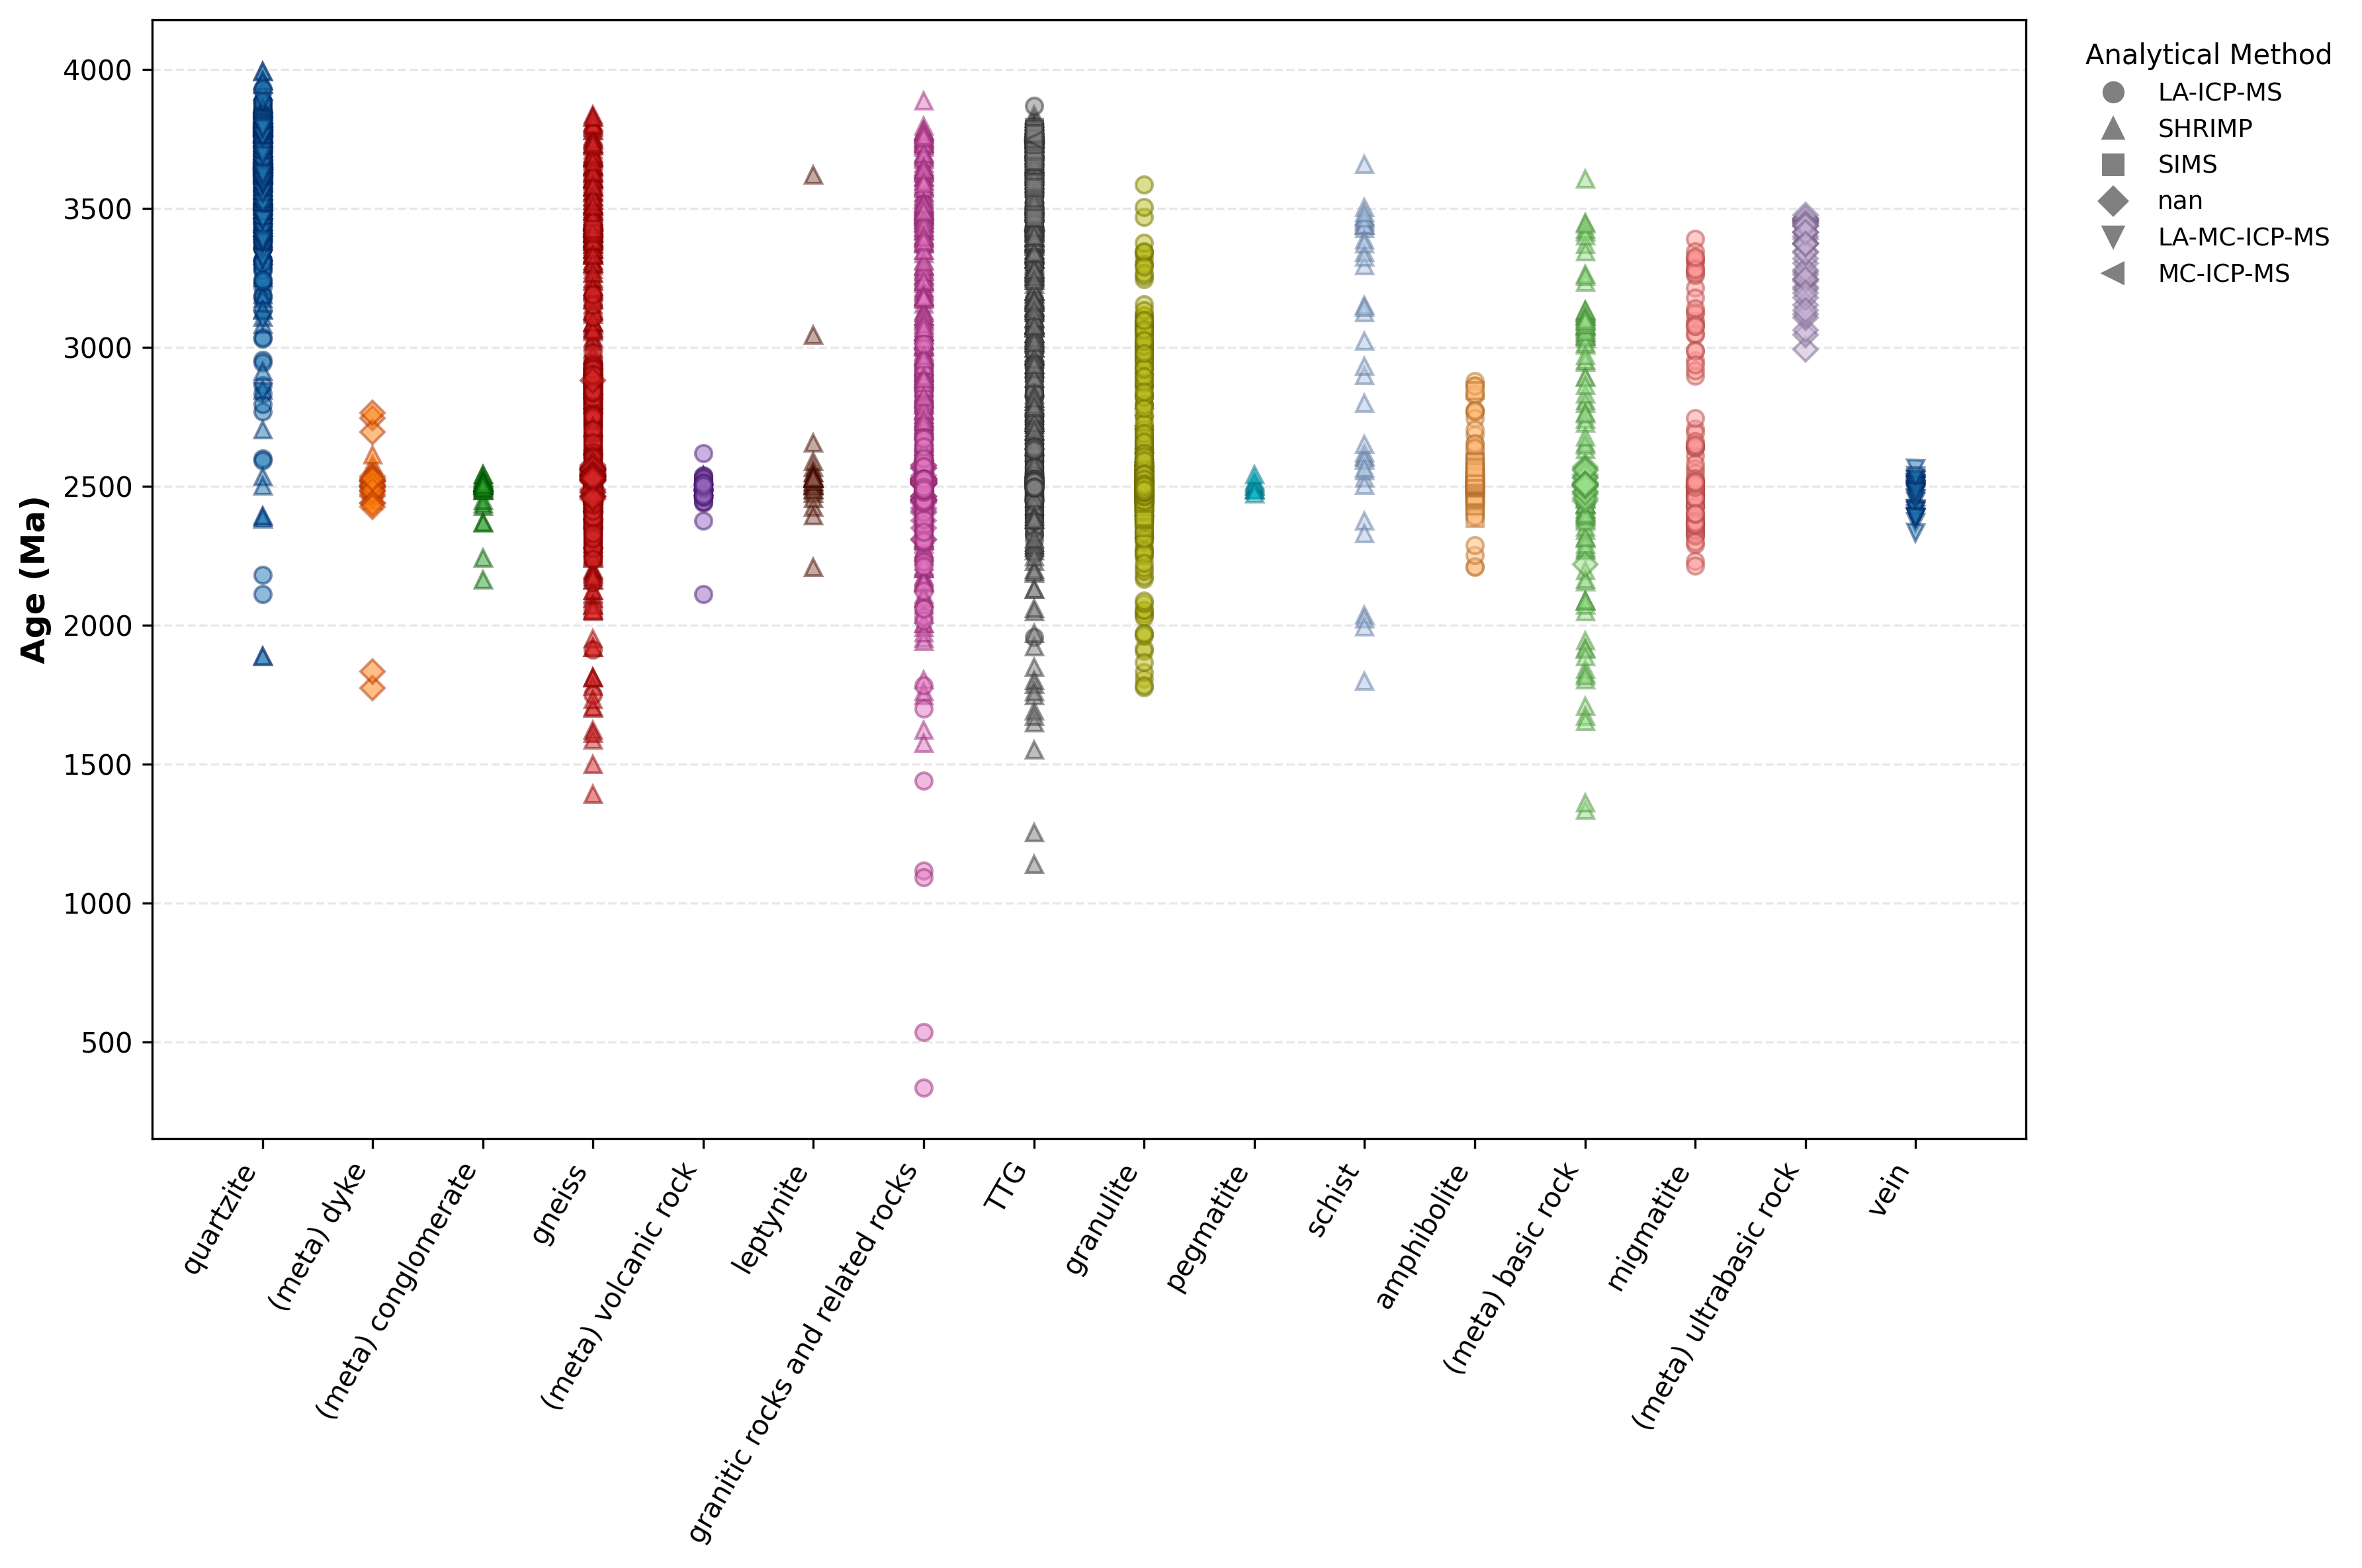


🎉 绘图全部完成！
📊 生成文件：
  - 散点图：Age_Distribution_Plot.svg / png
  - 统计表格：Analytical_Method_Count.xlsx / Rock_Type_Count.xlsx


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import matplotlib.colors as mc

# ====================== 彻底屏蔽所有警告 ======================
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.options.mode.chained_assignment = None
np.seterr(all='ignore')

# ====================== Jupyter 绘图设置 ======================
%matplotlib inline
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['font.size'] = 10

# 顶刊标准配色
COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

# 分析方法标记形状
MARKERS = ['o', '^', 's', 'D', 'v', '<', '>', 'p', '*', 'X']

# 工具函数：同色系加深颜色
def darken_color(color, amount=0.3):
    c = mc.to_rgb(color)
    return tuple(max(0, x - amount) for x in c)

# ====================== 交互式主函数 ======================
def plot_age_distribution():
    # 交互式输入
    file_path = input("请输入 Excel/CSV 文件路径：").strip().replace('"', '')
    age_col = input("请输入【年龄】列名：").strip()
    method_col = input("请输入【分析方法】列名：").strip()
    rock_col = input("请输入【岩石类型】列名：").strip()

    # 读取数据
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)
        print(f"\n✅ 文件读取成功！共 {df.shape[0]} 行，{df.shape[1]} 列")
        print(f"📋 列名：{list(df.columns)}\n")
    except Exception as e:
        print(f"❌ 读取失败：{e}")
        return

    # 检查列是否存在
    for col in [age_col, method_col, rock_col]:
        if col not in df.columns:
            print(f"❌ 列名不存在：{col}")
            return

    # 过滤年龄为空的行
    df_clean = df.dropna(subset=[age_col]).copy()
    print(f"✅ 有效数据行数：{len(df_clean)}")

    # 分析方法统计
    method_counts = df_clean[method_col].value_counts(dropna=False).reset_index()
    method_counts.columns = ['Analytical Method', 'Count']
    method_counts.to_excel("Analytical_Method_Count.xlsx", index=False)
    print("✅ 已生成：Analytical_Method_Count.xlsx")

    # 岩石类型统计
    rock_counts = df_clean[rock_col].value_counts(dropna=False).reset_index()
    rock_counts.columns = ['Rock Type', 'Count']
    rock_counts.to_excel("Rock_Type_Count.xlsx", index=False)
    print("✅ 已生成：Rock_Type_Count.xlsx")

    # 分配样式
    unique_methods = df_clean[method_col].unique()
    method_to_marker = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(unique_methods)}

    unique_rocks = df_clean[rock_col].unique()
    rock_to_color = {r: COLORS[i % len(COLORS)] for i, r in enumerate(unique_rocks)}

    x_pos_dict = {rock: i + 1 for i, rock in enumerate(unique_rocks)}
    df_clean['x_pos'] = df_clean[rock_col].map(x_pos_dict)

    # 绘图
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

    for idx, row in df_clean.iterrows():
        x = row['x_pos']
        y = row[age_col]
        marker = method_to_marker[row[method_col]]
        color_main = rock_to_color[row[rock_col]]
        edge_color = darken_color(color_main, 0.3)

        ax.plot(
            x, y,
            marker=marker,
            color=color_main,
            markeredgecolor=edge_color,
            markersize=6,
            alpha=0.5,
            linestyle=''
        )

    # 坐标轴
    ax.set_ylabel('Age (Ma)', fontsize=12, fontweight='bold')
    ax.set_xlim(0, len(unique_rocks) + 1)
    ax.set_xticks(list(x_pos_dict.values()))
    ax.set_xticklabels(list(x_pos_dict.keys()), rotation=60, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=10)

    # 图例
    legend_handles = []
    for method, marker in method_to_marker.items():
        h = plt.Line2D([], [], marker=marker, color='gray', linestyle='', markersize=7)
        legend_handles.append((h, method))

    handles, labels = zip(*legend_handles)
    ax.legend(
        handles, labels,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        title='Analytical Method',
        fontsize=9,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig("Age_Distribution_Plot.svg", format='svg', bbox_inches='tight')
    plt.savefig("Age_Distribution_Plot.png", dpi=300, bbox_inches='tight')
    
    # Jupyter 显示图片
    plt.show()
    plt.close()

    print("\n🎉 绘图全部完成！")
    print("📊 生成文件：")
    print("  - 散点图：Age_Distribution_Plot.svg / png")
    print("  - 统计表格：Analytical_Method_Count.xlsx / Rock_Type_Count.xlsx")

# ====================== 执行 ======================
plot_age_distribution()